In [1]:
from datetime import datetime
import math

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns
import shapely
from tqdm import tqdm

from wpp import data, db
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

root = project_root()
db_path = root / "rofl.duckdb"
con = db.connect(db_path)

In [3]:
states = con.sql("SELECT * FROM states").pl()
states

<sys>:0: UserWarning: Extension type 'geoarrow.wkb' is not registered; loading as its storage type.

To avoid this warning, register the extension type or set environment variable 'POLARS_UNKNOWN_EXTENSION_TYPE_BEHAVIOR' to 'load_as_storage' or 'load_as_extension'.

In Polars 2.0, the default behavior will change to 'load_as_extension'.


STATEFP,STATE,ABBR,GEOM
str,str,str,binary
"""12""","""Florida""","""FL""","b""\x01\x06\x00\x00\x00\x02\x00\x00\x00\x01\x03\x00\x00\x00\x01\x00\x00\x00&P\x00\x00Z\xf3\xe3/-\xe1U\xc0\x120\xba\xbc9H>@Z\xf3\xe3/-\xe1U\xc0Y\xdc\x7fd:H>@Z\xf3\xe3/-\xe1""…"
"""22""","""Louisiana""","""LA""","b""\x01\x03\x00\x00\x00\x01\x00\x00\x00,T\x00\x00\x91\x0ac\x0bAxW\xc0s\xbdm\xa6B\xd8?@\xdf\xa7\xaa\xd0@xW\xc0s\xbdm\xa6B\xd8?@\x0e\x12\xa2|AxW\xc0\xbf`7l[\xd8?""…"
"""28""","""Mississippi""","""MS""","b""\x01\x03\x00\x00\x00\x01\x00\x00\x00{d\x00\x004\xbcY\x83\xf7\xb5V\xc0\xd6\x90\xb8\xc7\xd2\xff>@j\xa2\xcfG\x19\xb6V\xc0/\xdc\xb90\xd2\xff>@\xec\x88C6\x90\xb6V\xc0\x11\xc3\x0ec\xd2\xff>""…"
"""17""","""Illinois""","""IL""","b""\x01\x03\x00\x00\x00\x01\x00\x00\x00MM\x00\x00\xb7\x9au\xc6\xf7\x98V\xc0\xdd[\x91\x98\xa0zC@:\xb0\x1c!\x03\x99V\xc0]6:\xe7\xa7zC@gd\x90\xbb\x08\x99V\xc0\xfc\xc5l\xc9\xaazC""…"
"""40""","""Oklahoma""","""OK""","b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\xcfR\x00\x00KW\xb0\x8dx\xa7X\xc0\xbc@I\x81\x05\x14A@6""\x18\x07\x97\xa7X\xc0\x9bWuV\x0b\x14A@\xaco`r\xa3\xa7X\xc0\x05\xa6\xd3\xba\x0d\x14A""…"
…,…,…,…
"""20""","""Kansas""","""KS""","b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\xf03\x00\x00/\x19\xc7H\xf69Y\xc0M\xf5d\xfe\xd1\x7fB@\xb5l\xad/\x12:Y\xc0k\x0e\x10\xcc\xd1\x7fB@8\x85\x95\x0a*:Y\xc0k\x0e\x10\xcc\xd1\x7fB""…"
"""24""","""Maryland""","""MD""","b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\xefe\x00\x00\xa2\xed\x98\xba+\xdfS\xc0\x0d\x18$}Z\xa5C@[A\xd3\x12+\xdfS\xc0\x00p\xec\xd9s\xa5C@V\xd2\x8ao(\xdfS\xc0\xb3?Pn\xdb\xa5C""…"
"""50""","""Vermont""","""VT""","b""\x01\x03\x00\x00\x00\x01\x00\x00\x00]/\x00\x00\xd2\xc5\xa6\x95BRR\xc0\xac\xe69""\xdfgE@\xa92\x8c\xbbARR\xc0E\xb94~\xe1gE@\xfd\xc0U\x9e@RR\xc0\x08\x1fJ\xb4\xe4gE""…"


In [15]:
pois = con.sql("""
    SELECT pois.*, s.STATEFP, s.STATE
    FROM pois
    JOIN block_groups bg 
      ON POI_CBG = GEOID
    JOIN states s
      ON bg.STATEFP = s.STATEFP""").pl()
pois

ID_STORE,BRAND,LOCATION_NAME,STREET_ADDRESS,POI_CBG,CITY,REGION,ISO_COUNTRY_CODE,TOP_CATEGORY,SUB_CATEGORY,OPEN_DATE,CLOSE_DATE,LONGITUDE,LATITUDE,GEOM,STATEFP,STATE
str,str,str,str,str,str,str,str,str,str,date,date,f64,f64,binary,str,str
"""2310093""","""Wendy's""","""The Wendy's Company""","""6815 Milwaukee Avenue""","""483030017162""","""Lubbock""","""TX""","""US""","""Restaurants and Other Eating P…","""Limited-Service Restaurants """,2016-08-23,2038-01-01,-101.956585,33.530426,"b""\x01\x01\x00\x00\x00f\xd5\x8c\xb18}Y\xc0\x1a\xb8M\x02\xe5\xc3@@""","""48""","""Texas"""
"""1593514""","""Denny's""","""Denny's Corporation""","""5534 Jimmy Carter Boulevard""","""131350504522""","""Norcross""","""GA""","""US""","""Restaurants and Other Eating P…","""Full-Service Restaurants """,1970-01-01,2038-01-01,-84.207275,33.909545,"b""\x01\x01\x00\x00\x001\xb1\x9e\xffC\x0dU\xc0X^M\xf9k\xf4@@""","""13""","""Georgia"""
"""6412477""","""Lyca Mobile""","""Lyca Mobile""","""S Main St""","""330110110003""","""Nashua""","""NH""","""US""","""Wired and Wireless Telecommuni…","""Wireless Telecommunications Ca…",1970-01-01,2038-01-01,-71.46115,42.74479,"b""\x01\x01\x00\x00\x00:#J{\x83\xddQ\xc0\xa51ZGU_E@""","""33""","""New Hampshire"""
"""6338398""","""AAMCO Transmissions""","""AAMCO Transmissions""","""235 Tennant Avenue""","""060855123102""","""Morgan Hill""","""CA""","""US""","""Automotive Repair and Maintena…","""Automotive Transmission Repair…",1970-01-01,2038-01-01,-121.639086,37.114951,"b""\x01\x01\x00\x00\x007U\xf7\xc8\xe6h^\xc0%\x90\x12\xbb\xb6\x8eB@""","""06""","""California"""
"""12138883""","""AAA/CAA Auto Repair - Authoriz…","""AAA/CAA Auto Repair - Authoriz…","""2114 S Ashland Ave""","""170313108003""","""Chicago""","""IL""","""US""","""Automotive Repair and Maintena…","""General Automotive Repair """,1970-01-01,2038-01-01,-87.666456,41.853802,"b""\x01\x01\x00\x00\x00E\x0e\x117\xa7\xeaU\xc04\xa1IbI\xedD@""","""17""","""Illinois"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""12262260""","""Wineries""","""Crane's Wine and Cider""","""435 Water St""","""260050309023""","""Saugatuck""","""MI""","""US""","""Beverage Manufacturing""","""Wineries """,1970-01-01,2038-01-01,-86.138375,42.593674,"b""\x01\x01\x00\x00\x00T\xc4\xe9$\xdb\x88U\xc0%>w\x82\xfdKE@""","""26""","""Michigan"""
"""11668895""","""Eye Med""","""Eye Med""","""2415 Tarpon Bay Blvd""","""120210104331""","""Naples""","""FL""","""US""","""Health and Personal Care Store…","""Optical Goods Stores """,1970-01-01,2038-01-01,-81.739901,26.270194,"b""\x01\x01\x00\x00\x00\xd2r\xa0\x87ZoT\xc0\x7f\x17\xb6f+E:@""","""12""","""Florida"""
"""8555162""","""Gift, Novelty, and Souvenir St…","""Gift, Novelty, and Souvenir St…","""4704 El Caballero Ct""","""484391115301""","""Arlington""","""TX""","""US""","""Office Supplies, Stationery, a…","""Gift, Novelty, and Souvenir St…",1970-01-01,2038-01-01,-97.148132,32.67038,"b""\x01\x01\x00\x00\x00\xcd\xfe\xe5\xffzIX\xc0\xe9\xf3\xac\xff\xceU@@""","""48""","""Texas"""


In [23]:
df = con.sql("""
    WITH bgv AS (
        SELECT HOME_CBG, POI_CBG, SUM(VISITOR_COUNT) AS VISITOR_COUNT
        FROM block_group_visits
        WHERE DATE_RANGE_START BETWEEN date'2025-01-01' AND date'2025-02-01'
        GROUP BY 1, 2
    ), bg_centroid AS (
        SELECT GEOID, STATEFP, ST_Centroid(GEOM) AS CENTROID
        FROM block_groups
    )
    SELECT 
        HOME_CBG, POI_CBG, 
        bgh.STATEFP AS HOME_STATE, bgp.STATEFP AS POI_STATE,
        ST_Distance_Sphere(bgh.CENTROID, bgp.CENTROID) AS DIST_METRES,
        VISITOR_COUNT,
        bgh.CENTROID AS HOME_GEOM, bgp.CENTROID AS POI_GEOM
    FROM bgv
    JOIN bg_centroid bgh
      ON bgv.HOME_CBG = bgh.GEOID
    JOIN bg_centroid bgp
      ON bgv.POI_CBG = bgp.GEOID
""").pl()
df

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

HOME_CBG,POI_CBG,HOME_STATE,POI_STATE,DIST_METRES,VISITOR_COUNT,HOME_GEOM,POI_GEOM
str,str,str,str,f64,"decimal[38,0]",binary,binary
"""360470052021""","""360610064001""","""36""","""36""",7388.133236,51,"b""\x01\x01\x00\x00\x00w\xd9\xd6\x0a\x8e\x82R\xc0hW<\xe1[OD@""","b""\x01\x01\x00\x00\x00\xc2\xb44\x85\xd9~R\xc0\xf1\xe0\xc2\x8a\x82^D@"""
"""360594149002""","""360610064001""","""36""","""36""",49580.967086,98,"b""\x01\x01\x00\x00\x00\x00b\xee\xd2RbR\xc0\xebN\xf6\x20\xdbXD@""","b""\x01\x01\x00\x00\x00\xc2\xb44\x85\xd9~R\xc0\xf1\xe0\xc2\x8a\x82^D@"""
"""170550406003""","""170810504003""","""17""","""17""",5683.858342,1697,"b""\x01\x01\x00\x00\x00\xb9\xa8\xd90R;V\xc0\x10E\xba<8\xfeB@""","b""\x01\x01\x00\x00\x00\xa0(\x06[\x0e8V\xc0\xc0\x00\xf7\x1d\xa6\x13C@"""
"""170550402002""","""170810504003""","""17""","""17""",15514.96569,1148,"b""\x01\x01\x00\x00\x00\xc4>P\x12\xfc@V\xc0`\xad\x04h\x03\x03C@""","b""\x01\x01\x00\x00\x00\xa0(\x06[\x0e8V\xc0\xc0\x00\xf7\x1d\xa6\x13C@"""
"""080690018123""","""080690010073""","""08""","""08""",6130.965376,13810,"b""\x01\x01\x00\x00\x00\xc8/\xf1\xe0VHZ\xc0\x0d\xc6\x9e\x06P>D@""","b""\x01\x01\x00\x00\x00\xd5k\xe3\xe2\xe1DZ\xc0\xbb(\x01k\xbfCD@"""
…,…,…,…,…,…,…,…
"""060710127001""","""060590762053""","""06""","""06""",34882.265263,133,"b""\x01\x01\x00\x00\x00\xf4\xca\xa4\xb0\x8cc]\xc0M\xec)""c\x06A@""","b""\x01\x01\x00\x00\x00\x17/\x8b\x84Wv]\xc0\xd6\x15\x18\x17\xfc\xe7@@"""
"""191130009012""","""190693602001""","""19""","""19""",166765.919668,26,"b""\x01\x01\x00\x00\x00EZ\x0cp\xec\xebV\xc0\x98\x18#\x0e.\x03E@""","b""\x01\x01\x00\x00\x00\xf4Zd\x1a\xe4KW\xc0rq\xf2\xe9Z]E@"""
"""360470492001""","""360810521002""","""36""","""36""",7997.717197,15,"b""\x01\x01\x00\x00\x00\x8cT\x12\x07&~R\xc0u\xf5\x19\xcckRD@""","b""\x01\x01\x00\x00\x00\x09%K\x18\xc0yR\xc0\xad\x99\xa1\x9f=\D@"""


In [41]:
poi_agg = pois.group_by("STATE").agg(pl.len().alias("NUM_POIS"))
agg = df.group_by("HOME_STATE").agg(
    ((pl.col("VISITOR_COUNT") * pl.col("DIST_METRES")).sum() / pl.col("VISITOR_COUNT").sum()).alias("AVG_DIST_METRES"),
    pl.col("VISITOR_COUNT").sum()
).join(
    states, left_on="HOME_STATE", right_on="STATEFP"
).join(
    poi_agg, on="STATE"
).sort("AVG_DIST_METRES", descending=True)

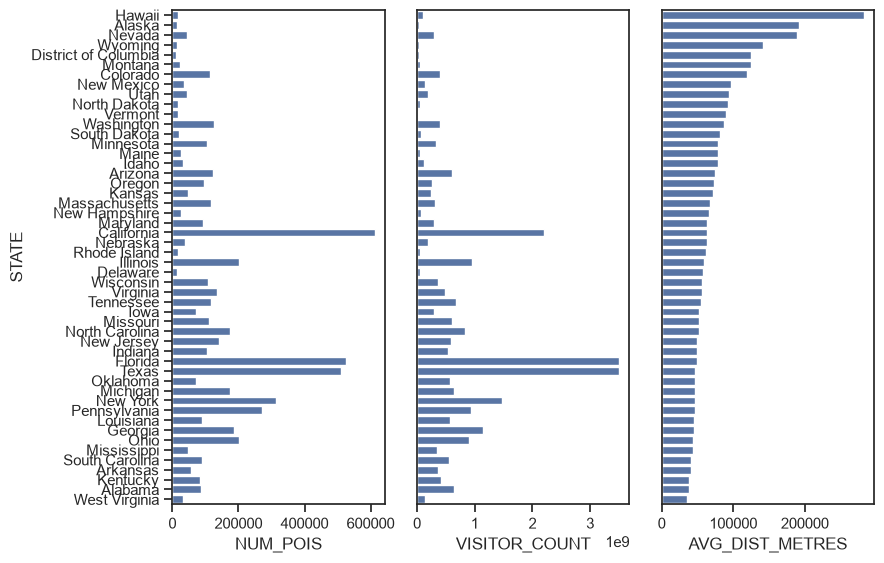

In [43]:
ncols = 3
fig, axes = plt.subplots(1, ncols, figsize=(3 * ncols, 5.8))
sns.barplot(agg, y="STATE", x="NUM_POIS", ax=axes[0])
sns.barplot(agg, y="STATE", x="VISITOR_COUNT", ax=axes[1])
sns.barplot(agg, y="STATE", x="AVG_DIST_METRES", ax=axes[2])
for i in range(1, len(axes)):
    axes[i].set_yticks([])
    axes[i].set_ylabel("")
fig.tight_layout()

In [52]:
df = con.sql("""
    SET preserve_insertion_order = false;
    PRAGMA max_temp_directory_size='200GiB';
    WITH bgv AS (
        SELECT HOME_CBG, POI_CBG, DATE_RANGE_START, SUM(VISITOR_COUNT) AS VISITOR_COUNT
        FROM block_group_visits
        WHERE DATE_RANGE_START BETWEEN date'2025-04-01' AND date'2025-09-01'
        GROUP BY 1, 2, 3
    ), bg_centroid AS (
        SELECT GEOID, STATEFP, ST_Centroid(GEOM) AS CENTROID
        FROM block_groups
    )
    SELECT 
        bgh.STATEFP, DATE_RANGE_START,
        SUM(ST_Distance_Sphere(bgh.CENTROID, bgp.CENTROID) * VISITOR_COUNT) / SUM(VISITOR_COUNT) AS AVG_DIST_METERS,
        SUM(VISITOR_COUNT) AS VISITOR_COUNT
    FROM bgv
    JOIN bg_centroid bgh
      ON bgv.HOME_CBG = bgh.GEOID
    JOIN bg_centroid bgp
      ON bgv.POI_CBG = bgp.GEOID
    GROUP BY 1, 2
""").pl()
df

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

STATEFP,DATE_RANGE_START,AVG_DIST_METERS,VISITOR_COUNT
str,datetime[μs],f64,"decimal[38,0]"
"""28""",2025-04-07 00:00:00,41686.355817,99637828
"""12""",2025-04-07 00:00:00,49598.53557,941629008
"""47""",2025-04-07 00:00:00,52577.106445,205204220
"""40""",2025-04-07 00:00:00,45551.555709,162184119
"""17""",2025-04-14 00:00:00,57841.55735,270871060
…,…,…,…
"""41""",2025-09-01 00:00:00,70291.772655,72676640
"""37""",2025-09-01 00:00:00,45394.761762,229405800
"""05""",2025-09-01 00:00:00,38836.363961,103055244


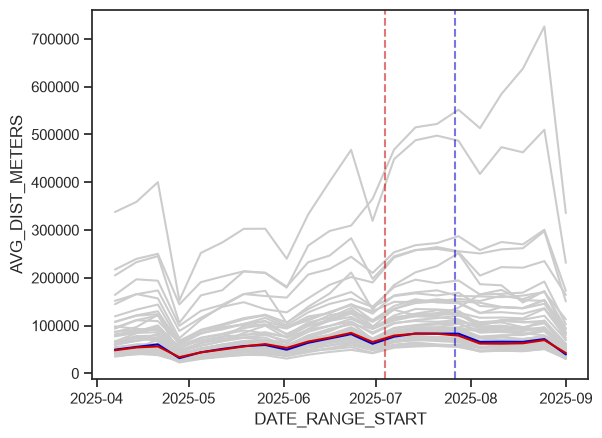

In [70]:
florida_heatwave_date = datetime.fromisoformat("2025-07-27")
texas_floods_date = datetime.fromisoformat("2025-07-04")

fig, ax = plt.subplots()
groups = sorted(df.group_by("STATEFP"), key=lambda item: item[0][0] in ('12', '48'))
for state, sdf in groups:
    hue = '#ccc'
    if state[0] == '48':
        hue = '#c00'
    elif state[0] == '12':
        hue = '#00c'
    sns.lineplot(
        sdf, 
        x="DATE_RANGE_START", y="AVG_DIST_METERS", 
        color=hue, legend=False, ax=ax,
    )
ax.axvline(florida_heatwave_date, color="#00c8", linestyle="--")
ax.axvline(texas_floods_date, color="#c008", linestyle="--")

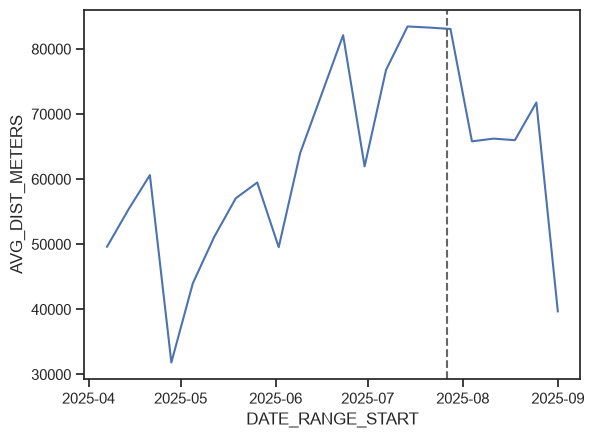

In [75]:
ax = sns.lineplot(
    df.filter(pl.col("STATEFP") == '12'),
    x="DATE_RANGE_START",
    y="AVG_DIST_METERS",
    legend=False
)
ax.axvline(florida_heatwave_date, color="#666", linestyle="--")